# 02. TPE Contact Detection

**Pipeline step 2 of 3** — classifies candidate particle pairs as *in contact* or *not in contact* using a ResNet18 model.

## Inputs
- Trajectory `.pkl` from Step 1 (positions, radii, boundary flags)
- Photoelastic images (`bw_*.png`)
- Pre-trained ResNet18 weights (`models/Contact_Detect_ResNet18.pth`)

## Outputs
- `CONTACT_BOND_<EXP_FOLDER>.pkl` — contact bond dataframe with columns:
  `i, j, xi, yi, xj, yj, ri, rj,prob, singular, frame`

## Workflow
1. Build all candidate bonds within $r_i + r_j + d_{tol}$
2. Run ResNet inference to classify each candidate
3. Post-process: drop singular-only pairs, duplicate bulk bonds for symmetry
4. Inspect a sample frame, then save

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import cv2
import sys
import torch
import torch.nn as nn
from torchvision import models as tv_models

sys.path.insert(0, os.getcwd())
import src

TorchScript enabled for StressSolve_residue_torch.


### Parameters — edit here before running

In [2]:
EXP_FOLDER = "TPE_20260518A03_N=262x2_step_shear_relax_e-3rpsx10s_stop100s_1fps_10reps"

TRAJ_DIR  = r'M:\Archive\Proj_TPE\Disk_traj_files'   # trajectory .pkl files
IMG_DIR   = r'N:\PROJ_TPE'                            # raw image root
BOND_DIR  = r'M:\Archive\Proj_TPE\Contact_bond_files' # output directory


########### FIXED PARAMETERS (EDIT AS NEEDED) #####################
filetype = ".png"
roi      = (250, 1200, 0, 2000)  # (y_min, y_max, x_min, x_max)
d_tol    = 10                    # neighbour distance tolerance [px]

# Derived paths
linked_file = os.path.join(TRAJ_DIR, f"{EXP_FOLDER}.pkl")
PE_dir      = os.path.join(IMG_DIR, EXP_FOLDER)
F = pd.read_pickle(linked_file)


### Read in tracked file, find all bonds that have length < $r_i + r_j +$ d_tol

output is F_bond that contains all potential bonds and boundary information

1. No boundary particles is on i 
2. Bulk - Bulk bonds are only counted once
3. Bonds with j on boundary are noted

In [3]:

F_bond = []

# Pre-group to avoid O(N) scan per frame
grouped_F = F.groupby('frame')

for frame in range(1, int(F.frame.max()) + 1):
    sys.stdout.write(f"\rBuilding bonds — frame: {frame}")
    sys.stdout.flush()

    if frame not in grouped_F.groups:
        continue
    f = grouped_F.get_group(frame).reset_index(drop=True)
    boundary_pid = f.particle[f.boundary].to_numpy()

    F_bond_temp, *_ = src.get_all_bonds(f, boundary_pid, d_tol)
    F_bond_temp['frame'] = frame
    F_bond.append(F_bond_temp)

F_bond = pd.concat(F_bond, ignore_index=True)
print(f"\nDone. {len(F_bond)} candidate bonds across {int(F.frame.max())} frames.")


Building bonds — frame: 1100
Done. 309029 candidate bonds across 1100 frames.


### Use model to distinguish contact or not, add contact column to F_bond

Cropped square has sides = $1.2 r_i$ 
Each contact point is only examined once

If both particles only have one contact (i.e. singular), the contact is deleted.

If either particle is singular, the contact is kept. The singular id is marked in the "singular" column

If neither are singular, singular column writes -1

Finally, ij pairs that are not on the boundary are cloned and swapped to ji

In [4]:
NUM_CLASSES = 2  # 0 = no contact, 1 = contact  (must match training)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = os.path.join(os.getcwd(), 'models', 'ResNet18_contact_finetuned.pth')

_backbone = tv_models.resnet18(weights=None)
_backbone.fc = nn.Sequential(
    nn.Linear(_backbone.fc.in_features, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, NUM_CLASSES)
)
_backbone.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model = _backbone.to(device).eval()

print(f"Model loaded: {model_path}")
print(f"Running on:   {device}")

Model loaded: o:\LJJ202107\LJJ Jupyter Notebook Collection\TPE_image_process_pipeline\models\ResNet18_contact_finetuned.pth
Running on:   cuda


In [9]:
all_frames = []
pred_frames = []

# Pre-group both dataframes to avoid O(N) scan per frame
grouped_F    = F.groupby('frame')
grouped_bond = F_bond.groupby('frame')

for frame in range(1, int(F.frame.max()) + 1):
#for frame in [500]:
    sys.stdout.write(f"\rClassifying contacts — frame: {frame}")
    sys.stdout.flush()

    if frame not in grouped_F.groups or frame not in grouped_bond.groups:
        continue

    # Load image
    PE_img_path = os.path.join(PE_dir, f'bw_{frame}{filetype}')
    I = cv2.imread(PE_img_path, cv2.IMREAD_GRAYSCALE)[roi[0]:roi[1], roi[2]:roi[3]]

    # Candidate bonds for this frame
    f_bond_frame = grouped_bond.get_group(frame).copy()

    # Run inference
    preds, _ = src.predict_contact_batch(f_bond_frame, I, model, plot_raw=False, batch_size=32)

    if preds.ndim != 2:
        raise ValueError(f"Expected (N, 2) predictions, got shape {preds.shape}")

    f_bond_frame['contact'] = np.argmax(preds, axis=1)
    f_bond_frame['prob'] = np.max(preds, axis=1)
    pred_frames.append(f_bond_frame)

if not pred_frames:
    raise ValueError('No candidate bonds were available for classification.')

# Temporal bridge: if pair is 1 at t-1 and t+1, promote t from 0 -> 1
F_pred = pd.concat(pred_frames, ignore_index=True)
F_pred = src.fill_temporal_single_frame_gaps(F_pred)

for frame in range(1, int(F.frame.max()) + 1):
    if frame not in grouped_F.groups:
        continue

    f = grouped_F.get_group(frame).copy()
    boundary_pid = f.particle[f.boundary.astype(bool)].to_numpy()

    f_bond_frame = F_pred[F_pred.frame == frame].copy()

    # Keep confirmed contacts only
    f_bond_frame = f_bond_frame[f_bond_frame.contact > 0]
    if f_bond_frame.empty:
        continue

    # Mark / drop singular bonds
    f_bond_frame = src.process_singular_bonds(f_bond_frame, boundary_pid)

    # Duplicate bulk bonds so every particle has contacts listed under i
    f_bond_frame = src.duplicate_and_swap_bulk(f_bond_frame)

    all_frames.append(f_bond_frame)

if not all_frames:
    raise ValueError('No contacts remained after temporal fill and singular-bond filtering.')

F_contact = pd.concat(all_frames, ignore_index=True).drop(columns=['contact'])
print(f"\nDone. {len(F_contact)} contact bonds across {int(F.frame.max())} frames.")

Classifying contacts — frame: 1100
Done. 370840 contact bonds across 1100 frames.


### Inspect results in one frame

Normal contacts in cyan

Singular contacts in magenta

3.1083333333333334


(np.float64(-0.5), np.float64(1599.5), np.float64(899.5), np.float64(-0.5))

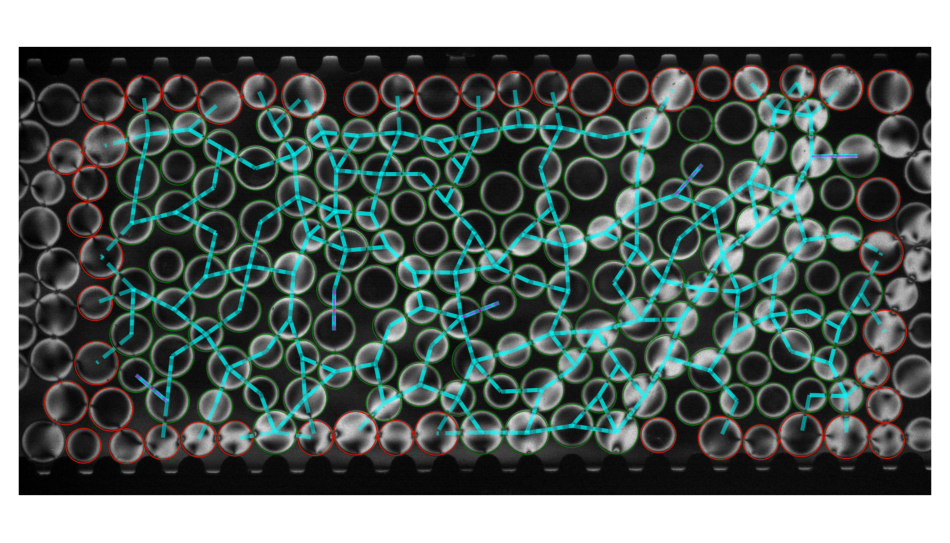

In [10]:
#pick random frame to visualize
frame = np.random.choice(F_contact['frame'].unique())
PE_img_path = os.path.join(PE_dir, f'bw_{frame}{filetype}')
I = cv2.imread(PE_img_path, cv2.IMREAD_GRAYSCALE)[roi[0]:roi[1], roi[2]:roi[3]]
f = F[F.frame==frame].copy() 

contact = F_contact[F_contact.frame==frame]['i'].value_counts()
z = contact[contact > 1].mean()
print(z)

plt.figure(figsize=(12, 8))
plt.imshow(src.plot_contacts(I, f, F_contact[F_contact.frame==frame], f.particle[f.boundary].to_numpy()))
plt.axis('off')

### Save results to disk

In [11]:
out_path = os.path.join(BOND_DIR, f"CONTACT_BOND_{EXP_FOLDER}.pkl")
F_contact.to_pickle(out_path)
print(f"Saved: {out_path}")
F_contact

Saved: M:\Archive\Proj_TPE\Contact_bond_files\CONTACT_BOND_TPE_20260518A03_N=262x2_step_shear_relax_e-3rpsx10s_stop100s_1fps_10reps.pkl


,i,xi,yi,ri,j,xj,yj,rj,j_on_boundary,frame,prob,singular
0,82,383.627742,758.062908,37.0,57,374.320910,835.061949,37.0,True,3,0.658815,82
1,105,1434.786434,164.402488,46.0,149,1499.185375,92.110638,46.0,True,3,0.638782,105
2,6,298.333822,441.132056,37.0,104,254.520471,366.543982,46.0,False,4,0.739445,104
3,6,298.333822,441.132056,37.0,186,327.269090,522.848786,46.0,False,4,0.965632,-1
4,72,399.948320,165.712743,37.0,16,425.277021,93.060419,37.0,True,4,0.523585,72
...,...,...,...,...,...,...,...,...,...,...,...,...
370835,185,1433.574611,725.776302,46.0,169,1487.007377,645.966911,46.0,False,1100,0.958137,-1
370836,189,545.445108,494.085939,46.0,173,594.573725,576.944001,46.0,False,1100,0.967367,-1
370837,180,875.062027,414.717189,46.0,176,970.674890,429.323946,46.0,False,1100,0.968131,-1
370838,187,461.343963,410.621909,46.0,182,471.604759,315.492988,46.0,False,1100,0.982205,-1
